In [43]:
import pandas
import torch
import torchvision
import glob

In [44]:
img_paths = glob.glob("WaterMeters/images/*.jpg")
mask_paths = glob.glob("WaterMeters/masks/*.jpg")

In [45]:
id_to_img = {}
id_to_val = {}

for i, path in enumerate(img_paths):
    id = int(path.split('/')[2].split("_")[1])
    v1 = int(path.split('/')[2].split("_")[3])
    v2 = int(path.split('/')[2].split("_")[4][:-4])

    id_to_img[id] = path.split('/')[2];
    id_to_val[id] = (v1, v2);

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TudorUnet(nn.Module):
    def __init__(self):
        super(TudorUnet, self).__init__()

        self.e1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.e2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.e3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.e4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.e5 = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.up5 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.d5 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d4 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d3 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.final = nn.Conv2d(64, 1, kernel_size=1) 

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        e5 = self.e5(self.pool(e4))

        d5 = self.up5(e5)
        d5 = self.d5(torch.cat([d5, e4], dim=1))

        d4 = self.up4(d5)
        d4 = self.d4(torch.cat([d4, e3], dim=1))

        d3 = self.up3(d4)
        d3 = self.d3(torch.cat([d3, e2], dim=1))

        d2 = self.up2(d3)
        d2 = self.d2(torch.cat([d2, e1], dim=1))

        out = self.final(d2)
        return out


In [47]:
import PIL.Image as Image
from PIL import ImageOps
import numpy as np
import tqdm

train_X = []
train_y = []

for i in tqdm.tqdm(range(4, len(img_paths) + 1, 1)):
    img = Image.open("WaterMeters/images/" + id_to_img[i])
    mask = Image.open("WaterMeters/masks/" + id_to_img[i])

    img = ImageOps.exif_transpose(img)
    mask = ImageOps.exif_transpose(mask)

    img = img.resize((128, 128))
    mask = mask.resize((128, 128))

    train_X.append(np.array(img))
    train_y.append(np.array(mask))

    

100%|██████████| 1241/1241 [00:38<00:00, 31.92it/s]


In [ ]:
from torchvision.transforms import v2

trns = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
])

for i in tqdm.tqdm(range(len(train_X))):
    img = train_X[i]

    for j in range(4):
        train_X.append(trns(img)) 
        train_y.append(train_y[i]) 
        

100%|██████████| 1241/1241 [00:00<00:00, 6898.77it/s]


In [49]:
len(train_X)

6205

In [50]:
train_X = np.array(train_X) / 255
train_y = np.array(train_y) / 255

In [51]:
np.random.shuffle(train_X)
np.random.shuffle(train_y)


In [52]:
# train_X

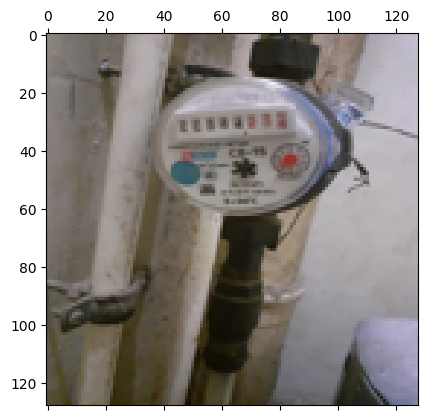

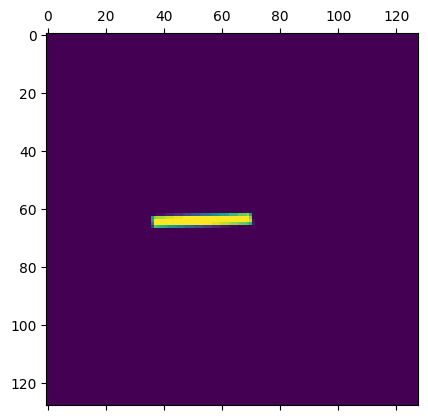

In [53]:
import matplotlib.pyplot as plt

plt.matshow(train_X[0])
plt.matshow(train_y[0])


In [54]:
batch_size = 30
device = torch.device("mps")
model = TudorUnet().to(device)
opt = torch.optim.Adam(model.parameters())
loss_fn = nn.MSELoss()


In [55]:
def train(epoch):
    print("Epoch:", epoch)

    train_loss = 0

    for i in tqdm.tqdm(range(0, len(train_X), batch_size)):
        X = torch.Tensor(train_X[i:i + batch_size]).permute(0, 3, 1, 2).to(device)
        y = torch.Tensor(train_y[i:i + batch_size]).to(device)

        opt.zero_grad()

        output = model(X)
        loss = loss_fn(output, y)

        loss.backward()
        opt.step()

        train_loss += loss.item()

    test_1 = torch.Tensor(train_X[0]).permute(2, 0, 1).to(device).reshape((1, 3, 128, 128))
    print(test_1.shape)
    pred_1 = model(test_1).detach().cpu().permute(0, 2, 3, 1).numpy()[0]
    print(pred_1.shape)

    plt.matshow(pred_1)
    plt.show()

    print("Loss:", train_loss / (len(train_X) / batch_size))



In [56]:
for i in range(10):
    train(i)

Epoch: 0


  0%|          | 0/207 [00:00<?, ?it/s]/Users/tudor/Documents/Work_AI/.venv_3.12/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([30, 128, 128])) that is different to the input size (torch.Size([30, 1, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
  0%|          | 0/207 [00:03<?, ?it/s]


KeyboardInterrupt: 